In [7]:
using LinearAlgebra
using StaticArrays
using Distributions
using Distances


using Plots                          # Plotting
using CSV, DataFrames, JLD2          # Data handling
using LinearAlgebra, StatsBase       # Linear algebra, statistics
using Random, Statistics             # Random number generation, basic statistics
using LaTeXStrings                   # LaTeX support for plots
using Revise                          # Live code reloading

using StaticArrays, LazySets          # Efficient arrays, set operations
using Interpolations, LinearInterpolations  # Interpolation utilities
using SpatiotemporalGPs               # Gaussian processes
using DifferentialEquations, ForwardDiff # Differential equations, automatic differentiation
using Distributions, StatsPlots, SpecialFunctions, Glob # Wind Transformatoins


In [8]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")
include("../src/transects.jl")

┌ Warning: Replacing docs for `Main.Variograms.hp_fit :: Tuple{Any}` in module `Main.Variograms`
└ @ Base.Docs docs\Docs.jl:243


Main.Transects

In [ ]:

# Define the exponential kernel (Matern-1/2)
function k_s(p::SVector{2, Float64}, p_prime::SVector{2, Float64}, σ_s::Float64, λ_s::Float64)
    dist = norm(p - p_prime)
    return σ_s^2 * exp(-dist / λ_s)
end

function S(r::SVector{2, Float64}, p::SVector{2, Float64}, σ_s, λ_s, σ_m, ΔT)
    k_pp = k_s(p, p, σ_s, λ_s)
    k_rr = k_s(r, r, σ_s, λ_s)
    k_rp = k_s(r, p, σ_s, λ_s)
    numerator = k_rp^2
    denominator = ΔT * k_pp * (k_rr + σ_m^2 - k_rp^2)
    return numerator / denominator
end

function D(q::Float64, λ_t::Float64, σ_t::Float64)
    return 2 * λ_t * ((σ_t^2 + 1) * q^2 - q)
end

function simulate_clarity(q0::Vector{Float64}, positions::Vector{Vector{SVector{2,Float64}}}, 
                          grid::Vector{SVector{2,Float64}}, dt::Float64, steps::Int, 
                          σ_s, λ_s, σ_m, ΔT, λ_t, σ_t)

    q = copy(q0)
    history = [copy(q)]

    for t in 1:steps

        if t == 2
            println("rlist: ", positions[t])
        end
        r_list = positions[t]
        dqdt = zeros(length(grid))

        for i in eachindex(grid)
            S_total = sum(S(r, grid[i], σ_s, λ_s, σ_m, ΔT) for r in r_list)
            D_val = D(q[i], λ_t, σ_t)
            dqdt[i] = S_total * (1 - q[i])^2 - D_val
        end

        q .+= dt .* dqdt
        push!(history, copy(q))
    end

    return history
end


simulate_clarity (generic function with 1 method)

In [50]:
file_path = "20250414_transect_lt15_ls10.jld2"
f = jldopen(file_path, "r")
transect_res_ergo_hp = f["res_ergo_hp"]
transect_synthetic_data = f["synthetic_data"]
transect_soc_target = f["soc_target"]
transect_ts_hrs = f["ts_hrs"]
transect_w_rated_val = f["w_rated_val"]
close(f)

In [61]:

# === Mission Setup ===
# Time parameters
Δt = 2.5                         # seconds
dt_min = Δt / 60                 # minutes
dt_hrs = Δt / 3600              # hours
T_begin = 9.0                   # hours
T_end = 12.0                    # hours
ts_hrs = T_begin:dt_hrs:T_end  # hours
ts_min = T_begin*60:dt_min:T_end*60

# Kernel parameters
σt = 1.0   # m/s
σs = 1.0   # m/s
σm = 0.5   # m/s
lt = 0.25 * 60.0 # minutes
ls = 1.0   # km

# Spatial domain
dx = 0.05 # km
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys])

# Initial clarity
q0 = zeros(length(grid_pts))

# Load actual robot positions
x0s = [transect_res_ergo_hp.xs[t] for t in 1:length(transect_res_ergo_hp.xs)]

# Simulate
clarity_history = simulate_clarity(q0, x0s, grid_pts, dt_min, length(ts_min), 
                                   σs, ls, σm, Δt, lt, σt)


4322-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0017678437413438824, 0.0019096403975407494, 0.00205804673984935, 0.002212136885762605, 0.0023706116404832037, 0.002531743753448648, 0.002693334516610306, 0.0028526922140658002, 0.003006645189211972, 0.0031516030635648008  …  0.0012557723754094345, 0.001209889177622409, 0.001161421155172148, 0.0011110345676952553, 0.0010593612787692466, 0.0010069868069419424, 0.0009544419869132305, 0.0009021979603816195, 0.0008506640680753937, 0.0008001881378273462]
 [0.005731439475511871, 0.006189934447699333, 0.006669608160705884, 0.007167443499693251, 0.007679222201119361, 0.0081993513303411, 0.00872072683383, 0.009234667721726755, 0.00973096148105908, 0.010198063575066543  …  0.004074158695611979, 0.003925547696116035, 0.0037685441200642064, 0.0036053032660746144, 0.0034378700557118396, 0.003268140321802903, 0.0030978337248002523, 0.002928477407007383, 0.

In [64]:
x0s

4321-element Vector{Vector{SVector{2, Float64}}}:
 [[0.75, 0.75]]
 [[0.7500012504145567, 0.7499967489221525]]
 [[0.7500038627730818, 0.7499899567899871]]
 [[0.7500077123997103, 0.7499799477607533]]
 [[0.7500128220908816, 0.7499666625637078]]
 [[0.7500192039517306, 0.7499500697255003]]
 [[0.7500268700868244, 0.7499301377742561]]
 [[0.7500358326000265, 0.7499068352399307]]
 [[0.7500461035943522, 0.749880130654684]]
 [[0.7500576951718165, 0.7498499925532767]]
 ⋮
 [[0.3234377719231977, 1.3745579165656578]]
 [[0.32464125961748863, 1.37527842635915]]
 [[0.3258447457769454, 1.3759989352337603]]
 [[0.3270482304019496, 1.376719443189717]]
 [[0.328251713492882, 1.3774399502272483]]
 [[0.32945519505012255, 1.3781604563465817]]
 [[0.3306586750740503, 1.3788809615479438]]
 [[0.3318621535650434, 1.3796014658315614]]
 [[0.3330656305234792, 1.3803219691976603]]

Plots.AnimatedGif("C:\\Users\\kavin\\AppData\\Local\\Temp\\jl_WdqXYXCZUX.gif")
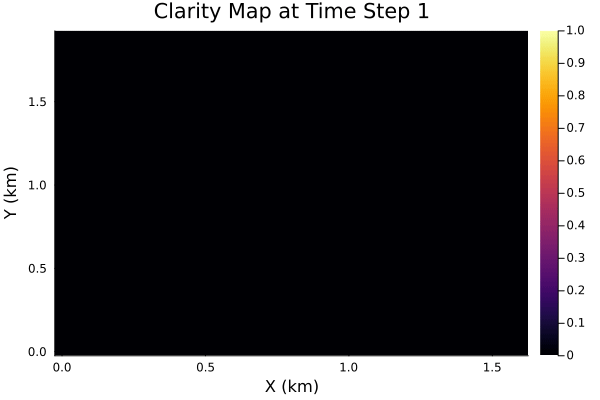

┌ Info: Saved animation to C:\Users\kavin\AppData\Local\Temp\jl_WdqXYXCZUX.gif
└ @ Plots C:\Users\kavin\.julia\packages\Plots\Ec1L1\src\animation.jl:156


In [52]:
@gif for i in 1:50:length(clarity_history)
    # Plot the clarity map
    clarity_reshape = reshape(clarity_history[i], length(xs), length(ys))
    heatmap(xs, ys, clarity_reshape', clims=(0,1), xlabel="X (km)", ylabel="Y (km)", title="Clarity Map at Time Step $i");
end

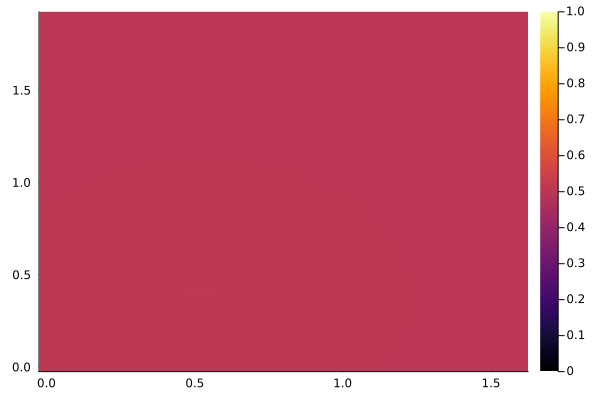

In [53]:
heatmap(xs, ys, reshape(clarity_history[1500]', length(xs), length(ys))', clims=(0,1))

┌ Info: Saved animation to C:\Users\kavin\AppData\Local\Temp\jl_eN2H21mxGj.gif
└ @ Plots C:\Users\kavin\.julia\packages\Plots\Ec1L1\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\kavin\\AppData\\Local\\Temp\\jl_eN2H21mxGj.gif")
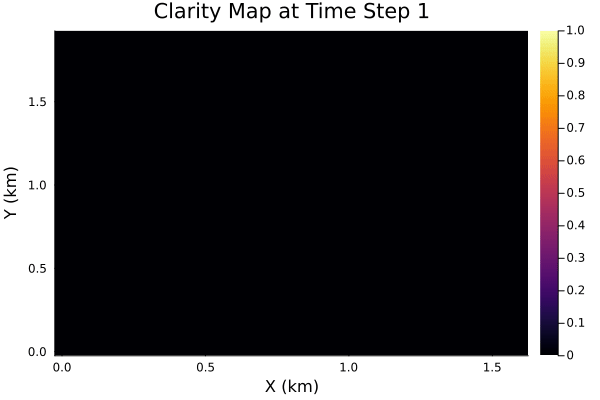

In [56]:
@gif for i in 1:10
    # Plot the clarity map
    clarity_reshape = reshape(clarity_history[i], length(xs), length(ys))
    heatmap(xs, ys, clarity_reshape', clims=(0,1), xlabel="X (km)", ylabel="Y (km)", title="Clarity Map at Time Step $i");
end